<a href="https://colab.research.google.com/github/PujanPandey07/Deep-Learning-/blob/main/MLP/neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Neural Network Classification with Pytorch
Classification is the process of predicting wheather some thing is one thing or another

# Make classification Data and get it ready


In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles
n_samples=1000
X,y=make_circles(n_samples,noise=0.03,random_state=42)

In [ ]:
print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


In [ ]:
print(X[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [ ]:
y[:5]

array([1, 1, 1, 1, 0])

In [ ]:
## Make Dataframe of circles Data
import pandas as pd
df=pd.DataFrame({"x1":X[:,0],"x2":X[:,1],"target":y})
df.head()

,x1,x2,target
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


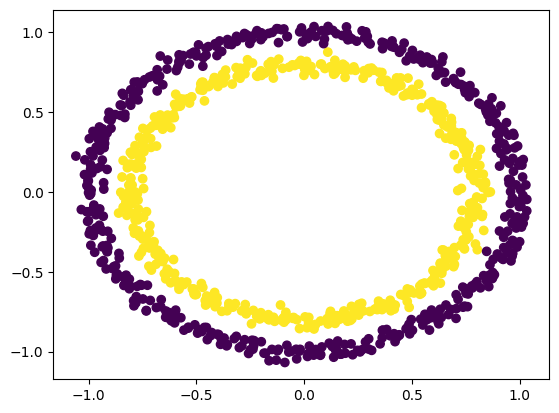

In [ ]:
## Visualize
import matplotlib.pyplot as plt
plt.scatter(df["x1"],df["x2"],c=df["target"])

## This type of dataset is called toydataset


In [ ]:
## turn data into Tensors
import torch
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [ ]:
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [ ]:
## Split data now in train and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

torch.Size([800, 2])

In [ ]:
y_train.shape

torch.Size([800])

In [ ]:
from torch import nn
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
# construct a module that subclasses nn.module
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=5)
    self.layer_2=nn.Linear(in_features=5,out_features=1)

  def forward(self,x):
    return self.layer_2(self.layer_1(x))
model_0=CircleModel().to(device)

In [ ]:
## Replacing above model with nn.sequential
model_0=nn.Sequential(nn.Linear(in_features=2,out_features=128),nn.Linear(in_features=128,out_features=256),nn.Linear(in_features=256,out_features=128),nn.Linear(in_features=128,out_features=1)).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): Linear(in_features=128, out_features=256, bias=True)
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
# make Predictions
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4398,  0.4413],
                      [-0.1661,  0.5507],
                      [ 0.3810, -0.5623],
                      [ 0.6698, -0.3586],
                      [-0.3138, -0.4229],
                      [-0.0103, -0.1156],
                      [-0.5101,  0.2631],
                      [ 0.5587,  0.0185],
                      [ 0.3283,  0.7022],
                      [-0.1524, -0.5748],
                      [-0.1957,  0.5765],
                      [ 0.4706, -0.1623],
                      [-0.1903,  0.2445],
                      [-0.6238, -0.0586],
                      [-0.5133,  0.6427],
                      [ 0.2891,  0.3843],
                      [-0.0727, -0.4947],
                      [-0.2840, -0.5980],
                      [ 0.3669,  0.4900],
                      [ 0.5299, -0.3277],
                      [-0.6361,  0.0608],
                      [-0.1720, -0.6992],
                      [ 0.0772, -0.3951],
        

In [ ]:
with torch.inference_mode():
   untrained_preds=model_0(X_test.to(device))
print(f"Length of predictions:{len(untrained_preds)}")
print(f"Shape of predictions:{untrained_preds.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")

Length of predictions:200
Shape of predictions:torch.Size([200, 1])

First 10 predictions:
tensor([[ 0.1493],
        [ 0.1906],
        [ 0.0049],
        [ 0.1904],
        [-0.0524],
        [-0.0268],
        [ 0.1350],
        [ 0.0839],
        [ 0.0075],
        [ 0.1927]])


In [ ]:
# selecting optimizer and building a training loop
loss_fn=torch.nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)


In [ ]:
#accuracy calculation function
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc
#

In [ ]:
# Training the model
'''we need to build a training loop
1.Forward pass
2.calculate Loss
3.Optimizer zero Grad
4.Loss backward(backpropagation)
5.Optimizer step(gradient descent)
our model outputs are going to be raw logits.we can convert these logits into prediction probabilities by passing them to some kind of activation function '''





'we need to build a training loop\n1.Forward pass\n2.calculate Loss\n3.Optimizer zero Grad\n4.Loss backward(backpropagation)\n5.Optimizer step(gradient descent)\nour model outputs are going to be raw logits.we can convert these logits into prediction probabilities by passing them to some kind of activation function '

In [ ]:
torch.manual_seed(42)
# set number of epochs
epochs=1000
#Building training loop
for epoch in range(epochs):
   model_0.train()
#1. Forward pass
   Y_logits=model_0(X_train).squeeze()
   y_pred=torch.round(torch.sigmoid(Y_logits))
#calculate loss
   loss=loss_fn(Y_logits,y_train)
#Optimizer zero Grad
   optimizer.zero_grad()

   acc=accuracy_fn(y_true=y_train,y_pred=y_pred)
#optimizer zero grad
   optimizer.zero_grad()
# loss backward
   loss.backward()
#optimizer step
   optimizer.step()
#testing
   model_0.eval()
   with torch.inference_mode():
     test_logits=model_0(X_test).squeeze()
     test_pred=torch.round(torch.sigmoid(test_logits))
     test_loss=loss_fn(test_logits,y_test)
     test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)
   if epoch % 5 == 0:
       print(f"Epoch:{epoch} | loss:{loss:.5f}  | accuracy : {acc:.2f} |tEST_loss :{test_loss}")






Epoch:0 | loss:0.69374  | accuracy : 52.75 |tEST_loss :0.6976825594902039
Epoch:5 | loss:0.69361  | accuracy : 52.25 |tEST_loss :0.6973960995674133
Epoch:10 | loss:0.69350  | accuracy : 52.00 |tEST_loss :0.6971495747566223
Epoch:15 | loss:0.69342  | accuracy : 51.88 |tEST_loss :0.6969351172447205
Epoch:20 | loss:0.69335  | accuracy : 51.88 |tEST_loss :0.696746826171875
Epoch:25 | loss:0.69329  | accuracy : 51.88 |tEST_loss :0.6965799927711487
Epoch:30 | loss:0.69325  | accuracy : 51.62 |tEST_loss :0.696431040763855
Epoch:35 | loss:0.69321  | accuracy : 52.12 |tEST_loss :0.6962974071502686
Epoch:40 | loss:0.69318  | accuracy : 51.75 |tEST_loss :0.6961765289306641
Epoch:45 | loss:0.69315  | accuracy : 51.62 |tEST_loss :0.6960669159889221
Epoch:50 | loss:0.69313  | accuracy : 51.25 |tEST_loss :0.6959667801856995
Epoch:55 | loss:0.69311  | accuracy : 51.12 |tEST_loss :0.6958754062652588
Epoch:60 | loss:0.69310  | accuracy : 51.25 |tEST_loss :0.695791482925415
Epoch:65 | loss:0.69308  | acc

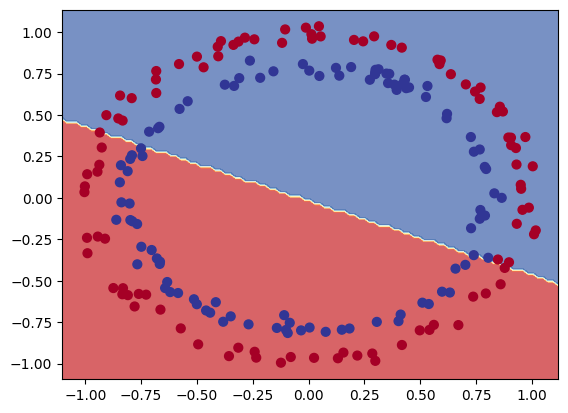

In [ ]:
# our model is not learning anything so lets visualize
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
  print("already exists")
else:
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)
from helper_functions import plot_predictions,plot_decision_boundary
plot_decision_boundary(model_0,X_test,y_test)


In [ ]:
#improving a model
#>add more layers
#>add more hidden units
#changing activating functions
#changing learning rate


## To add non Linearity we can use various non linear functions like RELU in between the sequential layers. Now lets do all we did in that apporach

In [ ]:
# making classification data ready
from sklearn.datasets import make_circles
n_samples=1000
X,y=make_circles(n_samples,noise=0.03,random_state=42)


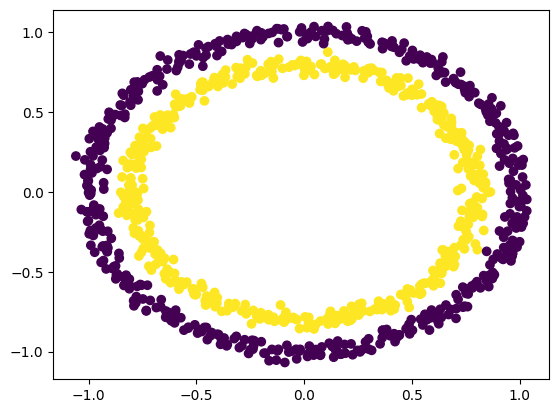

In [ ]:
# lets visualize our data at the start
plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
# Splitting the data into train and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
class circleclassify(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)           # no ReLU on output layer
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
model_1=circleclassify()

In [ ]:
model_1.state_dict()

OrderedDict([('network.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802],
                      [-0.3258, -0.0829],
                      [-0.2872,  0.4691],
                      [-0.5582, -0.3260],
                      [-0.1997, -0.4252],
                      [ 0.0667, -0.6984],
                      [ 0.6386, -0.6007],
                      [ 0.5459,  0.1177],
                      [-0.2296,  0.4370],
                      [ 0.1102,  0.5713],
                      [ 0.0773, -0.2230],
                      [ 0.1900, -0.1918],
                      [ 0.2976,  0.6313],
                      [ 0.4087, -0.3091],


In [ ]:
# now for training define loss functions and optimizers
loss_fn=torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)


In [ ]:
#accuracy calculation function
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc
#

In [ ]:
torch.manual_seed(42)
epochs = 1000

for epoch in range(epochs):
    # Training
    model_1.train()
    Y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(Y_logits))
    loss = loss_fn(Y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()       # ✅ model_1 not model_0
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 5 == 0:                                # ✅ inside loop, consistent indent
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.69146 | Acc: 59.38 | Test Loss: 0.68962 | Test Acc: 50.00
Epoch: 5 | Loss: 0.67389 | Acc: 51.12 | Test Loss: 0.67376 | Test Acc: 58.50
Epoch: 10 | Loss: 0.64434 | Acc: 83.25 | Test Loss: 0.64552 | Test Acc: 79.00
Epoch: 15 | Loss: 0.58979 | Acc: 97.00 | Test Loss: 0.59431 | Test Acc: 92.00
Epoch: 20 | Loss: 0.50155 | Acc: 99.00 | Test Loss: 0.51132 | Test Acc: 97.00
Epoch: 25 | Loss: 0.38033 | Acc: 99.75 | Test Loss: 0.39537 | Test Acc: 99.50
Epoch: 30 | Loss: 0.24601 | Acc: 99.88 | Test Loss: 0.26552 | Test Acc: 100.00
Epoch: 35 | Loss: 0.13385 | Acc: 100.00 | Test Loss: 0.15559 | Test Acc: 100.00
Epoch: 40 | Loss: 0.06510 | Acc: 100.00 | Test Loss: 0.08479 | Test Acc: 100.00
Epoch: 45 | Loss: 0.03195 | Acc: 100.00 | Test Loss: 0.04851 | Test Acc: 100.00
Epoch: 50 | Loss: 0.01716 | Acc: 100.00 | Test Loss: 0.03057 | Test Acc: 100.00
Epoch: 55 | Loss: 0.01043 | Acc: 100.00 | Test Loss: 0.02159 | Test Acc: 100.00
Epoch: 60 | Loss: 0.00709 | Acc: 100.00 | Test Loss: 0.

In [ ]:
print(y_train.dtype)  # must be torch.float32

# ✅ fix if it's int or long
y_train = y_train.float()
y_test  = y_test.float()


torch.float32


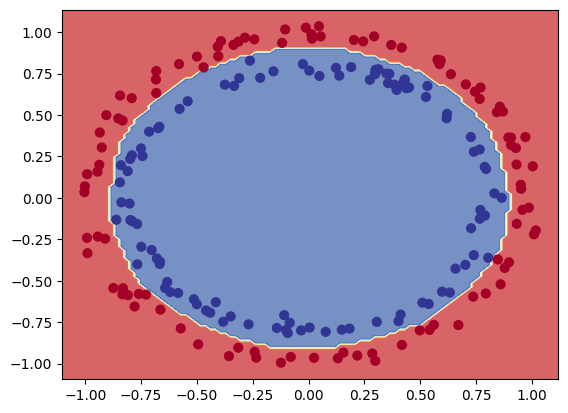

In [ ]:
plot_decision_boundary(model_1,X_test,y_test)
